In [1]:
import re
import datetime
import pathlib
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
VERSION = datetime.datetime.now().strftime("%y%m%d")
print(f"Execute Date: {VERSION}")

Execute Date: 260324


## Parameters for papermill

In [3]:
foldseek_result_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_output_human_proteome_v6_os_100_genes_9606.tsv")
query_uniprot_idmapping_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/os_100_genes_idmapping_all.tsv")
water_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_water")
needle_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_needle")
query_gene_list_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/oryza_sativa_random_100genes_list.tsv")
togoid_convert_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_target_species_togoid_convert.tsv")

In [4]:
# Parameters
foldseek_result_tsv = "/tmp/cp0kvfis/stgc9526eff-2308-49f9-a85f-8c2c22c7c3c6/foldseek_os_random_9606.tsv"
query_uniprot_idmapping_tsv = "/tmp/cp0kvfis/stg787887dc-15cd-4fdf-8322-b74627a930b5/at_100_genes_idmapping_all.tsv"
water_result_dir_path = "/tmp/cp0kvfis/stge33b7191-0fcf-439b-8c25-9544e6d99bc0/result_water"
needle_result_dir_path = "/tmp/cp0kvfis/stg6e696eb7-c426-4aa6-99e6-7963a8a6176b/result_needle"
query_gene_list_tsv_path = "/tmp/cp0kvfis/stg138143b3-5482-40a5-875b-5c334483f8a2/arabidopsis_random_100genes_list.tsv"
togoid_convert_tsv_path = "/tmp/cp0kvfis/stgd126e156-c5a9-4d74-b50c-5813f8343bf0/foldseek_hit_species_togoid_convert.tsv"


&nbsp;

&nbsp;

&nbsp;

## (1) Foldseek (Structural Alignment) Result

- Foldseek version: [10-941cd33](https://github.com/steineggerlab/foldseek/releases/tag/10-941cd33)
- About Column name: [foldseek GitHub page](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search)
- In this workflow, foldseek alignment type is `TM-align` (default). So, `e-value` column means `(qTMscore+tTMscore) / 2`
- More details: [TM-align Alignment mode](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#alignment-mode)

&nbsp;

### About Hit Pairs

- In this analysis workflow, the results are output with multiple hits remaining for a single query UniProt ID (protein structure).

&nbsp;

In [5]:
foldseek_result_df = pl.read_csv(
    foldseek_result_tsv,
    separator='\t'
).with_columns(
    (pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession")), # "?" means non-greedy
    (pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit"))
)

foldseek_result = pl.read_csv(
    query_uniprot_idmapping_tsv, # query idmapping
    separator='\t'
).join(
    foldseek_result_df,
    on="UniProt Accession",
    how="inner",
    coalesce=True
)

display(foldseek_result)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str
"""AT3G12900""","""Q9LE86""","""Q5SRE7""",0.507,0.353,26,7.7,0.077,28,61,342,357,1,279,291,360,0.79,0.959,0.4555,0.4757,0.5715,0.595,3.854,"""LSNLDGPQHKEVAKQIVEAAETLGFFQVVN…","""MA-C-------LSPSQLQKFQQDGFLVLEG…",173,"""0.361,0.263,0.257,0.283,0.438,…"
"""AT3G12900""","""Q9LE86""","""O14832""",0.495,0.411,30,6.5,0.065,24,48,344,357,18,304,338,369,0.832,0.849,0.4346,0.4987,0.5236,0.6071,4.147,"""QKALTCEATQPIDLSNLDGPQ---------…","""GRPSAGA-VVAHPTSG--TISSASFHPQQF…",191,"""0.121,0.205,0.169,0.221,0.327,…"
"""AT3G12900""","""Q9LE86""","""Q9NWT6""",0.4776,0.382,34,3.8,0.038,16,45,357,357,31,344,349,412,0.877,0.9,0.3838,0.4903,0.5001,0.5512,4.245,"""IPTQK-ALTCEATQPIDLSNLDGPQHKEVA…","""QLRSYSFPTRPI-PRLSQSDP------RAE…",199,"""0.143,0.310,0.423,0.474,0.518,…"
"""AT3G12900""","""Q9LE86""","""Q96Q83""",0.4762,0.277,28,7.0,0.07,27,39,338,357,12,286,286,383,0.84,0.962,0.4033,0.4458,0.542,0.5628,3.999,"""QPLS--------------------------…","""GAWAAPVKSQAIAQPATTAKSHLHQKPGQT…",165,"""0.069,0.086,0.113,0.072,0.216,…"
"""AT3G12900""","""Q9LE86""","""Q9NXW9""",0.4756,0.301,32,5.2,0.052,21,6,335,357,6,286,302,397,0.924,0.93,0.3721,0.462,0.5327,0.5675,4.98,"""EDQTTLFNFVVR----EGNGVKGMIDSGLS…","""AETPEVLRECGCKGIR----TC-LI---CE…",193,"""0.157,0.283,0.331,0.331,0.265,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AT1G50510""","""Q84K35""","""Q05923""",0.2922,0.076,42,1.8,0.018,8,11,313,330,16,311,314,430,0.918,0.943,0.2451,0.311,0.3216,0.335,6.916,"""SN-LQNHLSPLEANNKLRSLVKISPQVSEA…","""TLL-RDP----REAER-TL-LLDC------…",161,"""0.240,0.217,0.310,0.375,0.184,…"
"""AT1G50510""","""Q84K35""","""P46094""",0.2828,0.076,33,1.5,0.015,6,56,321,330,31,294,333,377,0.806,0.793,0.2926,0.3029,0.3007,0.3578,6.437,"""H-GMPYPQNLQTAKEVESIVRE-NG--A--…","""TL-ATTVLYCLVFLLSLVGNSLVLWVLVKY…",147,"""0.181,0.209,0.454,0.506,0.465,…"
"""AT1G50510""","""Q84K35""","""P28562""",0.2806,0.082,45,2.1,0.021,9,28,304,330,8,316,367,413,0.839,0.842,0.2466,0.3146,0.2908,0.3567,7.001,"""SLVKISPQVSEALSNGRAVVALE-STI---…","""LDAGGL--RALLGERAAQCLLLDCRSFFAF…",164,"""0.250,0.233,0.219,0.226,0.306,…"


&nbsp;

&nbsp;

## (2) Create Scatter Plot for all hits (Strucutural alignment identity vs LDDT)

- Identity in the results of the structural alignment is also output in the foldseek output.
- However, in this notebook, you can also select the results of the pairwise alignment of amino acid sequences (global alignment, local alignment).

&nbsp;

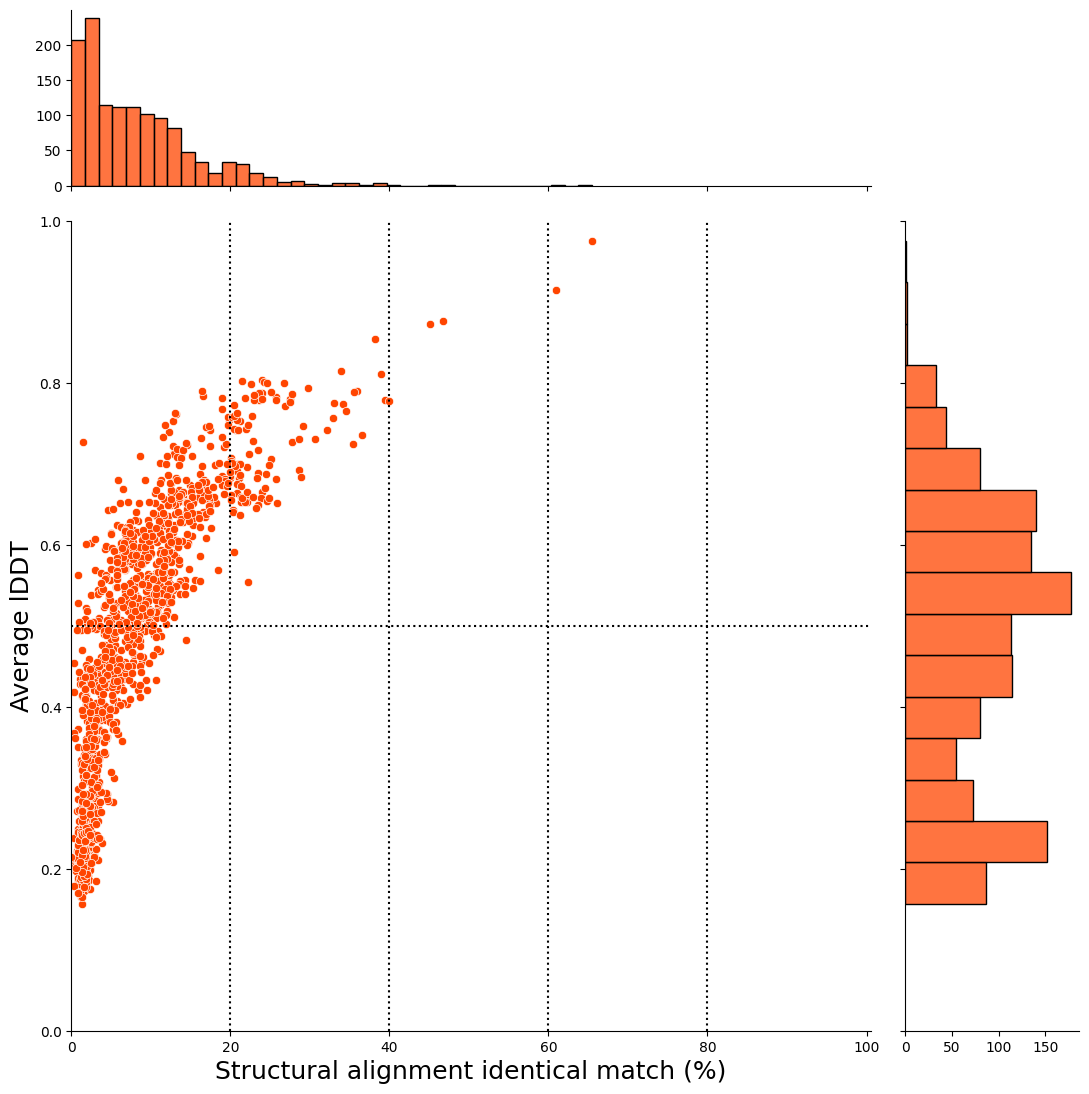

In [6]:
foldseek_filter_viz = foldseek_result.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz,
    x="pident", # structural alignment identical match from foldseek result
    y="lddt",
    color="orangered",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Structural alignment identical match (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# Save as PNG
plt.savefig(
    "foldseek_result_pident_lddt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (3) Parse protein sequence pairwise alignment result (water and needle)

- package: EMBOSS:6.5.7--4
- Score Subsutitution Matrix: EBLOSUM30 (For considering remote similarity)
- Website: [EMBOSS](https://emboss.sourceforge.net/)
- needle document: [EMBOSS needle](https://emboss.sourceforge.net/apps/release/6.0/emboss/apps/needle.html)
- water document: [EMBOSS water](https://emboss.sourceforge.net/apps/cvs/emboss/apps/water.html)
- EMBL-EBI Webserver: [EMBOSS NEEDLE](https://www.ebi.ac.uk/jdispatcher/psa/emboss_needle)
- EMBL-EBI Webserver: [EMBOSS WATER](https://www.ebi.ac.uk/jdispatcher/psa/emboss_water)

- For pairs hit by Foldseek (structural alignment), we perform analysis on the sequence similarity observed upon alignment at the `protein sequence level`.
- In other words, it is performing an alignment again on the pair of sequences, not just the regions aligned by Foldseek.

&nbsp;

In [7]:
def parse_needle_water_result(file_path: str | pathlib.Path) -> dict:
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.readlines()

    result = {
        "UniProt Accession": None,
        "foldseek hit": None,
        "Matrix": None,
        "Gap_penalty": None,
        "Extend_penalty": None,
        "Align_Length": None,
        "Identity": None,
        "Identity_percent": None,
        "Similarity": None,
        "Similarity_percent": None,
        "Gaps": None,
        "Gaps_percent": None,
        "Score": None,
        "Longest_Identity": None,
        "Longest_Similarity": None,
        "Shortest_Identity": None,
        "Shortest_Similarity": None,
    }

    for line in data:
        if line.startswith("# 1:"):
            result['UniProt Accession'] = line.split(":")[1].strip()
        elif line.startswith("# 2:"):
            result["foldseek hit"] = line.split(":")[1].strip()
        elif line.startswith("# Matrix:"):
            result["Matrix"] = line.split(":")[1].strip()
        elif line.startswith("# Gap_penalty:"):
            result["Gap_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Extend_penalty:"):
            result["Extend_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Length:"):
            result["Align_Length"] = int(line.split()[2])
        elif line.startswith("# Identity:"):
            result["Identity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Identity_percent"] = float(m.group(1))
        elif line.startswith("# Similarity:"):
            result["Similarity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Similarity_percent"] = float(m.group(1))
        elif line.startswith("# Gaps:"):
            result["Gaps"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Gaps_percent"] = float(m.group(1))
        elif line.startswith("# Score:"):
            result["Score"] = float(line.split()[2])
        elif line.startswith("# Longest_Identity"):
            result["Longest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Longest_Similarity"):
            result["Longest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Identity"):
            result["Shortest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Similarity"):
            result["Shortest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )

    return result

In [8]:
water_result_dir = pathlib.Path(water_result_dir_path)
needle_result_dir = pathlib.Path(needle_result_dir_path)

# Initialize empty lists to store DataFrames
water_dfs = []
needle_dfs = []

# Collect all water results
for result_file in water_result_dir.glob("*_align.water"):
    parsed_data = parse_needle_water_result(result_file)
    water_dfs.append(pl.DataFrame([parsed_data]))

# Collect all needle results    
for result_file in needle_result_dir.glob("*_align.needle"):
    parsed_data = parse_needle_water_result(result_file)
    needle_dfs.append(pl.DataFrame([parsed_data]))

# Combine all results and sort only if there are results
water_result = (pl.concat(water_dfs, how='vertical')
                .sort(["UniProt Accession", "foldseek hit"]) 
                if water_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

needle_result = (pl.concat(needle_dfs, how='vertical')
                 .sort(["UniProt Accession", "foldseek hit"])
                 if needle_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

display(water_result)
display(needle_result)

UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A7XDQ9""","""O00219""","""EBLOSUM30""",10.0,0.5,751,"""126/751""",16.8,"""252/751""",33.6,"""293/751""",39.0,490.0,27.51,55.02,18.42,36.84
"""A7XDQ9""","""O00469""","""EBLOSUM30""",10.0,0.5,846,"""142/846""",16.8,"""287/846""",33.9,"""348/846""",41.1,557.0,28.51,57.63,19.27,38.94
"""A7XDQ9""","""O60568""","""EBLOSUM30""",10.0,0.5,805,"""167/805""",20.7,"""289/805""",35.9,"""256/805""",31.8,558.5,30.42,52.64,22.63,39.16
"""A7XDQ9""","""P07225""","""EBLOSUM30""",10.0,0.5,705,"""131/705""",18.6,"""250/705""",35.5,"""238/705""",33.8,436.0,28.05,53.53,19.15,36.55
"""A7XDQ9""","""P11171""","""EBLOSUM30""",10.0,0.5,813,"""150/813""",18.5,"""292/813""",35.9,"""300/813""",36.9,470.0,29.24,56.92,17.36,33.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9ZW35""","""O14734""","""EBLOSUM30""",10.0,0.5,296,"""46/296""",15.5,"""98/296""",33.1,"""94/296""",31.8,141.0,22.77,48.51,14.42,30.72
"""Q9ZW35""","""O60671""","""EBLOSUM30""",10.0,0.5,252,"""48/252""",19.0,"""112/252""",44.4,"""36/252""",14.3,226.5,22.22,51.85,17.02,39.72
"""Q9ZW35""","""O60921""","""EBLOSUM30""",10.0,0.5,295,"""52/295""",17.6,"""118/295""",40.0,"""57/295""",19.3,165.5,21.85,49.58,18.57,42.14


UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A7XDQ9""","""O00219""","""EBLOSUM30""",10.0,0.5,772,"""125/772""",16.2,"""252/772""",32.6,"""307/772""",39.8,486.0,26.88,54.19,18.27,36.84
"""A7XDQ9""","""O00469""","""EBLOSUM30""",10.0,0.5,909,"""146/909""",16.1,"""294/909""",32.3,"""397/909""",43.7,546.5,28.52,57.42,19.81,39.89
"""A7XDQ9""","""O60568""","""EBLOSUM30""",10.0,0.5,857,"""167/857""",19.5,"""297/857""",34.7,"""292/857""",34.1,558.0,29.56,52.57,22.63,40.24
"""A7XDQ9""","""P07225""","""EBLOSUM30""",10.0,0.5,880,"""133/880""",15.1,"""255/880""",29.0,"""400/880""",45.5,429.0,27.71,53.12,19.44,37.28
"""A7XDQ9""","""P11171""","""EBLOSUM30""",10.0,0.5,1002,"""146/1002""",14.6,"""297/1002""",29.6,"""456/1002""",45.5,467.0,26.74,54.4,16.9,34.38
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9ZW35""","""O14734""","""EBLOSUM30""",10.0,0.5,380,"""46/380""",12.1,"""98/380""",25.8,"""177/380""",46.6,140.0,22.66,48.28,14.42,30.72
"""Q9ZW35""","""O60671""","""EBLOSUM30""",10.0,0.5,328,"""54/328""",16.5,"""122/328""",37.2,"""110/328""",33.5,225.5,24.77,55.96,19.15,43.26
"""Q9ZW35""","""O60921""","""EBLOSUM30""",10.0,0.5,305,"""52/305""",17.0,"""118/305""",38.7,"""66/305""",21.6,165.5,21.76,49.37,18.57,42.14


In [9]:
alignment_result = water_result.join(
    needle_result,
    on=["UniProt Accession", "foldseek hit"],
    how="inner",
    coalesce=True,
    suffix="_needle"
).rename(
    {
        "Align_Length": "Align_Length_water",
        "Identity": "Identity_water",
        "Identity_percent": "Identity_percent_water",
        "Similarity": "Similarity_water",
        "Similarity_percent": "Similarity_percent_water",
        "Gaps": "Gaps_water",
        "Gaps_percent": "Gaps_percent_water",
        "Longest_Identity": "Longest_Identity_water",
        "Longest_Similarity": "Longest_Similarity_water",
        "Shortest_Identity": "Shortest_Identity_water",
        "Shortest_Similarity": "Shortest_Similarity_water",
        "Score": "Score_water"
    }
).select(
    [
        "UniProt Accession",
        "foldseek hit",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_needle",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_needle",
        "Gaps_percent_water",
        "Gaps_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
)

display(alignment_result)

UniProt Accession,foldseek hit,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""A7XDQ9""","""O00219""",751,772,"""126/751""","""125/772""",16.8,16.2,33.6,32.6,"""293/751""","""307/772""",39.0,39.8,18.42,18.27,27.51,26.88,36.84,36.84,55.02,54.19,490.0,486.0,10.0,0.5,"""EBLOSUM30"""
"""A7XDQ9""","""O00469""",846,909,"""142/846""","""146/909""",16.8,16.1,33.9,32.3,"""348/846""","""397/909""",41.1,43.7,19.27,19.81,28.51,28.52,38.94,39.89,57.63,57.42,557.0,546.5,10.0,0.5,"""EBLOSUM30"""
"""A7XDQ9""","""O60568""",805,857,"""167/805""","""167/857""",20.7,19.5,35.9,34.7,"""256/805""","""292/857""",31.8,34.1,22.63,22.63,30.42,29.56,39.16,40.24,52.64,52.57,558.5,558.0,10.0,0.5,"""EBLOSUM30"""
"""A7XDQ9""","""P07225""",705,880,"""131/705""","""133/880""",18.6,15.1,35.5,29.0,"""238/705""","""400/880""",33.8,45.5,19.15,19.44,28.05,27.71,36.55,37.28,53.53,53.12,436.0,429.0,10.0,0.5,"""EBLOSUM30"""
"""A7XDQ9""","""P11171""",813,1002,"""150/813""","""146/1002""",18.5,14.6,35.9,29.6,"""300/813""","""456/1002""",36.9,45.5,17.36,16.9,29.24,26.74,33.8,34.38,56.92,54.4,470.0,467.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9ZW35""","""O14734""",296,380,"""46/296""","""46/380""",15.5,12.1,33.1,25.8,"""94/296""","""177/380""",31.8,46.6,14.42,14.42,22.77,22.66,30.72,30.72,48.51,48.28,141.0,140.0,10.0,0.5,"""EBLOSUM30"""
"""Q9ZW35""","""O60671""",252,328,"""48/252""","""54/328""",19.0,16.5,44.4,37.2,"""36/252""","""110/328""",14.3,33.5,17.02,19.15,22.22,24.77,39.72,43.26,51.85,55.96,226.5,225.5,10.0,0.5,"""EBLOSUM30"""
"""Q9ZW35""","""O60921""",295,305,"""52/295""","""52/305""",17.6,17.0,40.0,38.7,"""57/295""","""66/305""",19.3,21.6,18.57,18.57,21.85,21.76,42.14,42.14,49.58,49.37,165.5,165.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (4) Integrate foldseek result and pairwise alignment result

- This time, **exclude the ones that are null in pairwise alignment result, which means the current UniProt entry is obsolete**

In [10]:
join_foldseek = foldseek_result.join(
    alignment_result,
    on=["UniProt Accession", "foldseek hit"],
    how="left",
    coalesce=True
).filter( # filter out null alignment result (this means current UniProt entry is obsolete)
    pl.col("Align_Length_water").is_not_null() & 
    pl.col("Align_Length_needle").is_not_null()
).unique()

join_foldseek.write_csv(
    "foldseek_result_join_alignment_result_all.tsv",
    separator='\t'
)


display(join_foldseek)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""AT3G12900""","""Q9LE86""","""Q9H9V9""",0.4206,0.301,33,3.5,0.035,16,51,357,357,26,387,417,450,0.86,0.868,0.3724,0.4673,0.4092,0.5305,5.134,"""LTCEATQPIDLSNLDGPQHKEVAKQIVEAA…","""APGRVAFVSEPGAFS---YADFVRGFLL-P…",203,"""0.279,0.310,0.314,0.541,0.619,…",476,492,"""87/476""","""87/492""",18.3,17.7,33.6,32.5,"""196/476""","""210/492""",41.2,42.7,20.86,20.86,31.07,30.85,38.37,38.37,57.14,56.74,258.0,256.0,10.0,0.5,"""EBLOSUM30"""
"""AT3G01090""","""Q38997""","""P07948""",0.4405,0.301,13,22.1,0.221,63,14,280,512,242,507,512,284,0.521,0.52,0.6576,0.4466,0.4466,0.8252,2.998,"""SILPNYKLGRTLGIGSFGRVKIAEHALTGH…","""IPRESIKLVKRLGAGQFGEVWMGYYNN-ST…",186,"""0.321,0.432,0.538,0.612,0.510,…",356,750,"""93/356""","""93/750""",26.1,12.4,43.0,20.8,"""98/356""","""476/750""",27.5,63.5,18.16,18.16,36.05,33.94,29.88,30.47,59.3,56.93,461.5,460.0,10.0,0.5,"""EBLOSUM30"""
"""AT2G41090""","""P30187""","""A0PJX0""",0.447,0.301,30,7.9,0.079,17,1,190,191,18,184,185,215,0.995,0.903,0.4639,0.4791,0.491,0.5313,5.39,"""MA--NKFTRQQISEFREQFSVYDKNG--DG…","""QALT-FLTR-NEI-LCIHDTFLKLCPPGKY…",125,"""0.438,0.545,0.410,0.455,0.421,…",220,233,"""41/220""","""40/233""",18.6,17.2,37.3,36.5,"""79/220""","""90/233""",35.9,38.6,21.47,20.94,29.08,27.97,42.93,44.5,58.16,59.44,206.5,202.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G73410""","""Q9FX36""","""Q3ZCU0""",0.2265,0.045,19,2.4,0.024,6,19,184,243,64,240,254,250,0.683,0.697,0.4365,0.2485,0.2402,0.3266,5.731,"""DLVEQYGPHNW-------------------…","""GRPVTHRTDDNIQKVKDLVCSNRQLTVRMM…",87,"""0.114,0.094,0.159,0.323,0.231,…",253,303,"""46/253""","""46/303""",18.2,15.2,36.4,30.7,"""63/253""","""109/303""",24.9,36.0,18.11,18.11,24.21,23.71,36.22,36.61,48.42,47.94,183.0,180.0,10.0,0.5,"""EBLOSUM30"""
"""AT3G01090""","""Q38997""","""Q05513""",0.4836,0.505,7,20.2,0.202,77,14,331,512,247,591,592,381,0.621,0.583,0.7575,0.5215,0.453,0.8276,2.553,"""SILPNYKLGRTLGIGSFGRVKIAEHALTGH…","""LGLQDFDLIRVIGRGSYAKVLLVRLKKNDQ…",205,"""0.330,0.500,0.688,0.651,0.595,…",378,791,"""99/378""","""106/791""",26.2,13.4,48.4,24.4,"""92/378""","""478/791""",24.3,60.4,16.72,17.91,34.62,33.87,30.91,32.6,63.99,61.66,565.0,564.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AT3G19600""","""F4JCB2""","""Q9H611""",0.2133,0.034,55,1.4,0.014,12,121,597,601,14,600,641,845,0.794,0.916,0.2004,0.2308,0.2198,0.2683,8.235,"""STTREDLWKMKVRGDPISITIEH----LVK…","""DSELRCRVAVEELSPGGQPRRRQALRTAEL…",207,"""0.170,0.176,0.263,0.229,0.197,…",681,766,"""128/681""","""136/766""",18.8,17.8,37.4,34.5,"""230/681""","""290/766""",33.8,37.9,19.97,21.22,28.38,28.57,39.78,41.19,56.54,55.46,406.5,395.0,10.0,0.5,"""EBLOSUM30"""
"""AT1G65250""","""O80795""","""Q9HBH9""",0.5009,0.632,30,11.9,0.119,43,38,345,372,73,374,465,360,0.828,0.649,0.5137,0.5658,0.4617,0.6837,4.104,"""KFFSADEILKATNDFSDSNFVLRLEVPFKW…","""DSFSGRFEDVYQ--LQE--DVLGEGAHARV…",207,"""0.069,0.103,0.135,0.222,0.301,…",488,523,"""97/488""","""97/523""",19.9,18.5,36.9,34.4,"""178/488""","""209/523""",36.5,40.0,20.86,20.86,31.29,30.89,38.71,38.71,58.06,57.32,342.5,337.5,10.0,0.5,"""EB

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (5) Create Scatter Plot for all hits (x-axis: Similarity_percent_needle) Global alignment

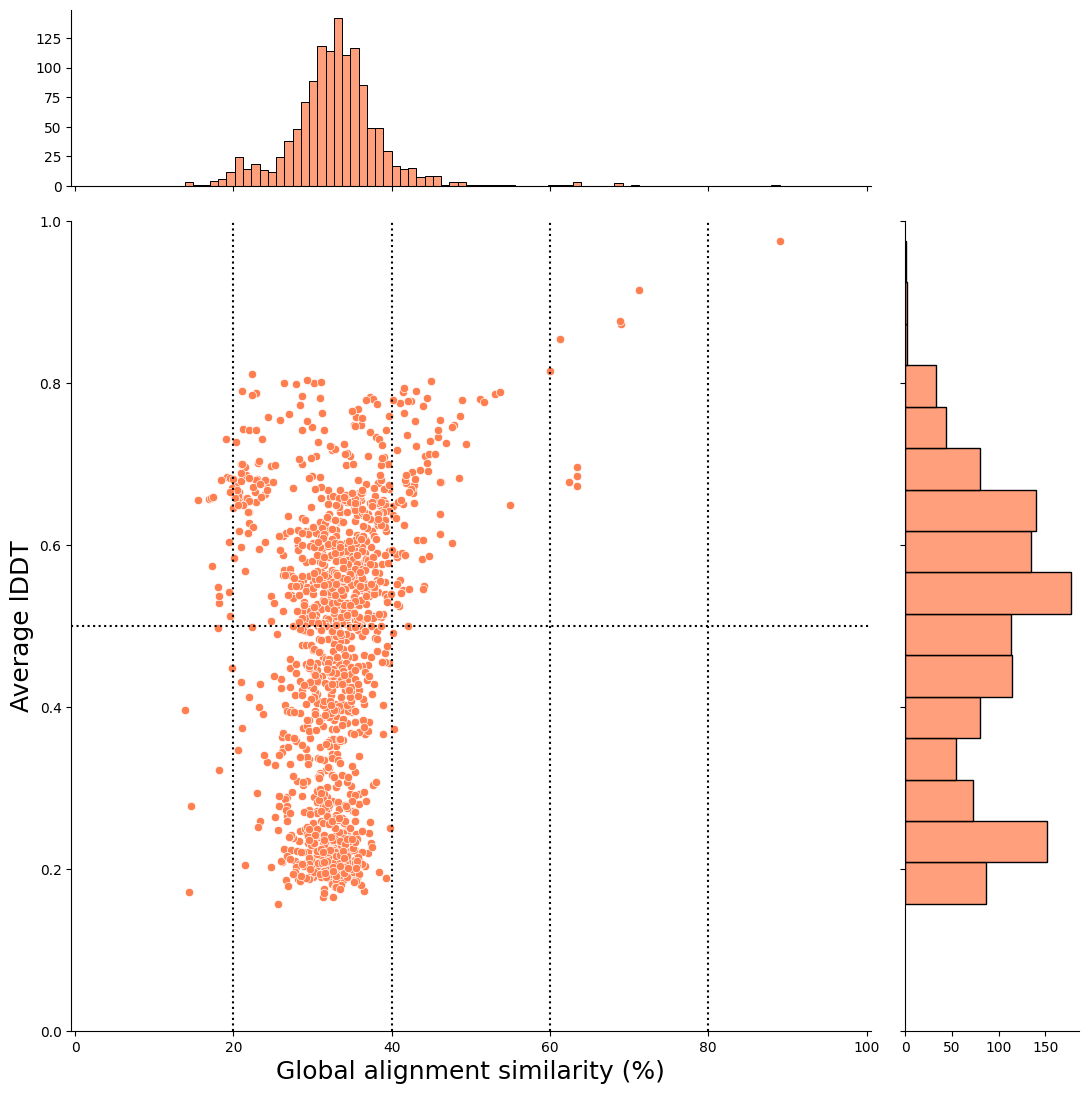

In [11]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100.5)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## Create Scatter Plot for all hits (x-axis: Similarity_percent_water) Local Alignment

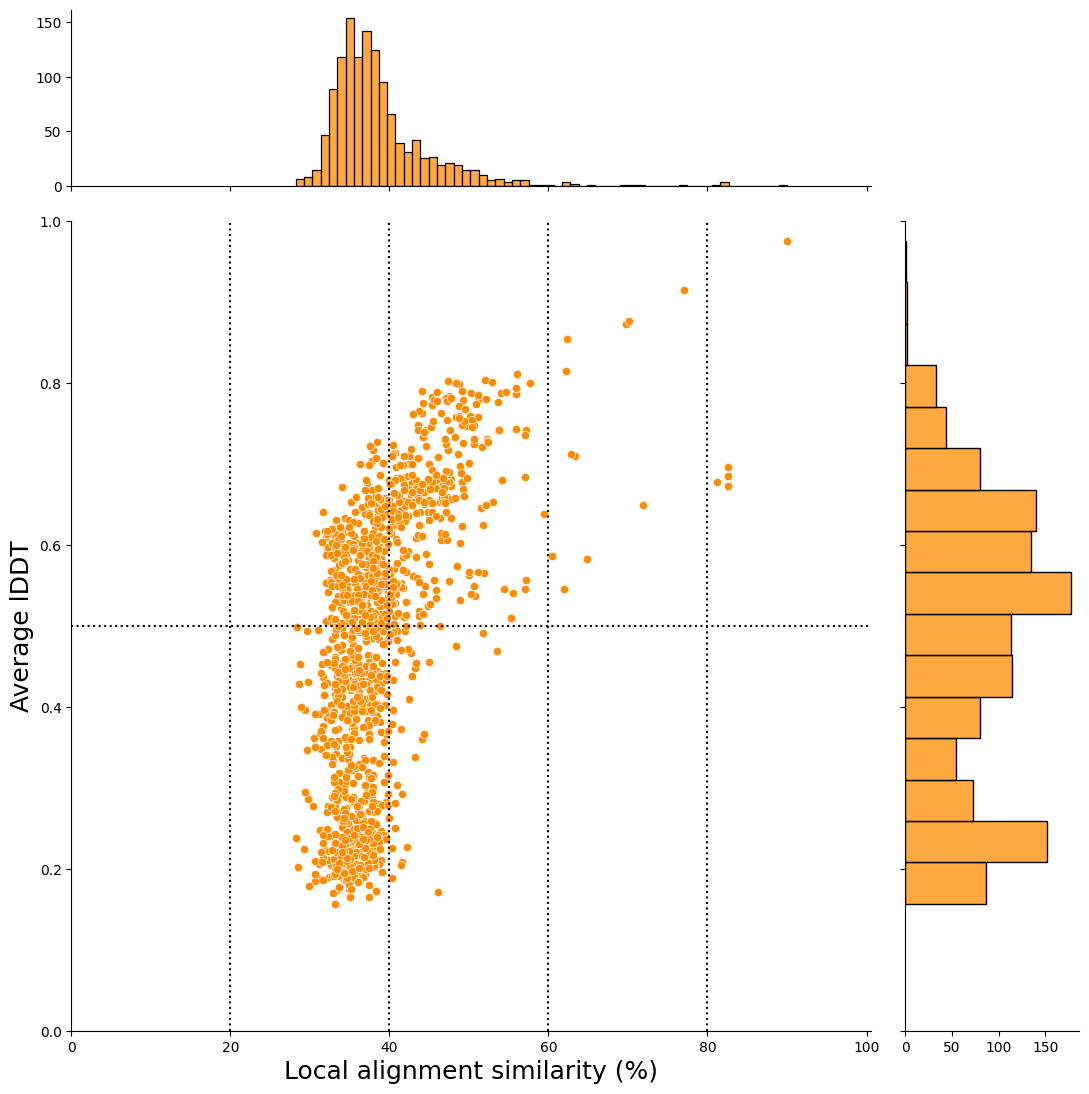

In [12]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_water", # local alignment similarity
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (6) Counting foldseek hits in Gene level

In [13]:
all_gene_list = pl.read_csv(
    query_gene_list_tsv_path,
    separator='\t'
).select(
    "From"
).unique()

hit_count = all_gene_list.join(
    join_foldseek,
    on="From",
    how="left",
    coalesce=True
).group_by("From", maintain_order=True).agg(
    (pl.col("foldseek hit").count().alias("target hit count (gene level vs uniprot accession)")),
    (pl.col("foldseek hit").is_null().all().alias("foldseek no hit"))
).sort(
    ["target hit count (gene level vs uniprot accession)"], descending=True
)

hit_count.write_csv(
    "foldseek_result_gene_level_hit_count_all.tsv",
    separator='\t'
)

display(hit_count)

From,target hit count (gene level vs uniprot accession),foldseek no hit
str,u32,bool
"""AT3G01090""",209,false
"""AT5G39000""",186,false
"""AT1G65250""",131,false
"""AT5G57190""",88,false
"""AT2G38220""",78,false
…,…,…
"""AT1G03040""",0,true
"""AT3G07975""",0,true
"""AT4G10603""",0,true


&nbsp;

&nbsp;

&nbsp;

# Caution:

- The filtering steps that are executed below can be changed freely.

&nbsp;

## (7) Filtering Condition1

- alignment coverage `>= 0.5`

In [14]:
condition1 = join_foldseek.filter(
        (pl.col("qcov") >= 0.5) &
        (pl.col("tcov") >= 0.5)
    ).sort(
        by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession
        descending=[False, False, False]
    )

condition1_rm = condition1.filter(
        (pl.col("qcov") < 0.5) |
        (pl.col("tcov") < 0.5)
    )

print(condition1.group_by(["From"], maintain_order=True).n_unique())
display(condition1)

shape: (27, 52)
┌───────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬────────────┬────────┐
│ From      ┆ UniProt    ┆ foldseek   ┆ evalue ┆ … ┆ Score_need ┆ Gap_penalt ┆ Extend_pen ┆ Matrix │
│ ---       ┆ Accession  ┆ hit        ┆ ---    ┆   ┆ le         ┆ y          ┆ alty       ┆ ---    │
│ str       ┆ ---        ┆ ---        ┆ u32    ┆   ┆ ---        ┆ ---        ┆ ---        ┆ u32    │
│           ┆ u32        ┆ u32        ┆        ┆   ┆ u32        ┆ u32        ┆ u32        ┆        │
╞═══════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪════════════╪════════╡
│ AT1G03445 ┆ 1          ┆ 42         ┆ 42     ┆ … ┆ 41         ┆ 1          ┆ 1          ┆ 1      │
│ AT1G21880 ┆ 1          ┆ 1          ┆ 1      ┆ … ┆ 1          ┆ 1          ┆ 1          ┆ 1      │
│ AT1G31770 ┆ 1          ┆ 11         ┆ 11     ┆ … ┆ 11         ┆ 1          ┆ 1          ┆ 1      │
│ AT1G50510 ┆ 1          ┆ 15         ┆ 15     ┆ … ┆ 14         ┆ 1        

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""AT1G03445""","""Q9LR78""","""A2RRH5""",0.2913,0.082,37,2.6,0.026,27,1,603,793,81,808,827,1049,0.76,0.88,0.4024,0.3032,0.292,0.3865,4.836,"""M-----------------------------…","""NKVNPLLICSASLDYVIMWNLDECREKVLQ…",255,"""0.150,0.208,0.500,0.333,0.458,…",940,980,"""166/940""","""166/980""",17.7,16.9,35.5,34.3,"""300/940""","""340/980""",31.9,34.7,20.07,20.07,25.94,25.94,40.39,40.63,52.19,52.5,550.5,544.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""A4D1B5""",0.2435,0.057,75,1.9,0.019,20,21,793,793,18,630,854,1057,0.975,0.718,0.1972,0.2635,0.2494,0.3155,8.729,"""YDTDEDWPGP-----------------RCG…","""WLRAQRAVSEASGAGSGGADVLENDYE---…",309,"""0.243,0.375,0.443,0.320,0.250,…",948,1047,"""178/948""","""180/1047""",18.8,17.2,34.5,31.4,"""356/948""","""447/1047""",37.6,42.7,20.84,21.08,30.07,30.0,38.29,38.52,55.24,54.83,588.0,577.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O14829""",0.427,0.179,23,11.3,0.113,90,126,793,793,62,525,653,795,0.842,0.711,0.6798,0.391,0.4709,0.6517,3.911,"""DVYMLDMTNNKWIKFLVGGETPSPRYGHVM…","""FFSFML-----ENYT--------------H…",247,"""0.047,0.057,0.079,0.120,0.087,…",622,1053,"""150/622""","""149/1053""",24.1,14.2,40.7,24.0,"""226/622""","""660/1053""",36.3,62.7,18.92,18.79,37.88,37.91,31.9,31.9,63.89,64.38,787.5,783.0,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O14830""",0.4039,0.196,29,11.1,0.111,100,92,793,793,70,606,753,898,0.885,0.713,0.676,0.3974,0.4177,0.5765,3.679,"""IGDVPSPRACHAAALYGTLILIQGGIGPSG…","""MDHFIPSSH-NDRDFLTRIF----------…",241,"""0.125,0.193,0.152,0.175,0.138,…",725,1124,"""160/725""","""160/1124""",22.1,14.2,37.2,24.1,"""315/725""","""702/1124""",43.4,62.5,20.18,20.18,39.02,37.91,34.05,34.17,65.85,64.22,843.0,837.0,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O15033""",0.2141,0.034,65,1.4,0.014,18,16,787,793,31,816,823,1282,0.974,0.955,0.2302,0.2274,0.221,0.232,8.672,"""S--IQTFYDTDED-----------WPGPR-…","""SFL-QNEDRERRGDRTIYDYVRGNYLDPRS…",258,"""0.033,0.179,0.173,0.159,0.176,…",914,973,"""153/914""","""156/973""",16.7,16.0,36.2,34.1,"""272/914""","""330/973""",29.8,33.9,18.59,18.96,23.83,24.26,40.22,40.34,51.56,51.63,571.5,567.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AT5G64040""","""P49107""","""P42857""",0.2131,0.034,11,2.5,0.025,4,38,146,171,7,115,185,154,0.637,0.589,0.5381,0.2397,0.2256,0.3285,5.216,"""QKKQ--------------------------…","""NFAEKGTKQPLLEDGFDTIPLMTPLDVNQL…",60,"""0.375,0.306,0.375,0.306,0.556,…",166,245,"""32/166""","""35/245""",19.3,14.3,36.1,27.3,"""65/166""","""134/245""",39.2,54.7,17.3,18.92,31.68,31.53,32.43,36.22,59.41,60.36,108.5,108.5,10.0,0.5,"""EBLOSUM30"""
"""AT5G64040""","""P49107""","""Q16695""",0.2171,0.029,10,3.6,0.036,6,17,153,171,14,101,136,166,0.801,0.647,0.4416,0.2223,0.2618,0.3501,4.916,"""GSG-SVELNQKV------------------…","""GKAPRKQLATKVARKSAPATGGVKKPHRYR…",53,"""0.312,0.406,0.333,0.531,0.639,…",134,201,"""30/134""","""29/201""",22.4,14.4,39.6,27.9,"""33/134""","""95/201""",24.6,47.3,17.54,16.96,29.7,27.36,30.99,32.75,52.48,52.83,100.5,91.5,10.

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (8) Filtering Condition2

- If there are hits with the same target for the same gene-derived UniProt ID, the one with the highest qcov is selected, and if the qcov is the same, the one with the highest lDDT is selected.
- **Note that in this study, we leave the states with the same foldseek hit even if the rice genes are different.**

In [15]:
condition2 = condition1.sort(
    by=["qcov", "lddt"],
    descending=[True, True]
).group_by(
    ["From", "foldseek hit"],
    maintain_order=True
).agg(
    pl.all().first()
).sort(
    by=["From", "UniProt Accession", "foldseek hit"],
    descending=[False, False, False]
).select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "evalue",
    "prob",
    "gapopen",
    "pident",
    "fident",
    "nident",
    "qstart",
    "qend",
    "qlen",
    "tstart",
    "tend",
    "tlen",
    "alnlen",
    "qcov",
    "tcov",
    "lddt",
    "qtmscore",
    "ttmscore",
    "alntmscore",
    "rmsd",
    "mismatch",
    "Align_Length_water",
    "Align_Length_needle",
    "Identity_water",
    "Identity_needle",
    "Identity_percent_water",
    "Identity_percent_needle",
    "Similarity_percent_water",
    "Similarity_percent_needle",
    "Shortest_Identity_water",
    "Shortest_Identity_needle",
    "Longest_Identity_water",
    "Longest_Identity_needle",
    "Shortest_Similarity_water",
    "Shortest_Similarity_needle",
    "Longest_Similarity_water",
    "Longest_Similarity_needle",
    "Gaps_water",
    "Gaps_percent_water",
    "Gaps_needle",
    "Gaps_percent_needle",
    "Score_water",
    "Score_needle",
    "Gap_penalty",
    "Extend_penalty",
    "Matrix"
)

display(condition2)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,mismatch,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""AT1G03445""","""Q9LR78""","""A2RRH5""",0.2913,0.082,37,2.6,0.026,27,1,603,793,81,808,827,1049,0.76,0.88,0.4024,0.3032,0.292,0.3865,4.836,255,940,980,"""166/940""","""166/980""",17.7,16.9,35.5,34.3,20.07,20.07,25.94,25.94,40.39,40.63,52.19,52.5,"""300/940""",31.9,"""340/980""",34.7,550.5,544.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""A4D1B5""",0.2435,0.057,75,1.9,0.019,20,21,793,793,18,630,854,1057,0.975,0.718,0.1972,0.2635,0.2494,0.3155,8.729,309,948,1047,"""178/948""","""180/1047""",18.8,17.2,34.5,31.4,20.84,21.08,30.07,30.0,38.29,38.52,55.24,54.83,"""356/948""",37.6,"""447/1047""",42.7,588.0,577.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O14829""",0.427,0.179,23,11.3,0.113,90,126,793,793,62,525,653,795,0.842,0.711,0.6798,0.391,0.4709,0.6517,3.911,247,622,1053,"""150/622""","""149/1053""",24.1,14.2,40.7,24.0,18.92,18.79,37.88,37.91,31.9,31.9,63.89,64.38,"""226/622""",36.3,"""660/1053""",62.7,787.5,783.0,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O14830""",0.4039,0.196,29,11.1,0.111,100,92,793,793,70,606,753,898,0.885,0.713,0.676,0.3974,0.4177,0.5765,3.679,241,725,1124,"""160/725""","""160/1124""",22.1,14.2,37.2,24.1,20.18,20.18,39.02,37.91,34.05,34.17,65.85,64.22,"""315/725""",43.4,"""702/1124""",62.5,843.0,837.0,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O15033""",0.2141,0.034,65,1.4,0.014,18,16,787,793,31,816,823,1282,0.974,0.955,0.2302,0.2274,0.221,0.232,8.672,258,914,973,"""153/914""","""156/973""",16.7,16.0,36.2,34.1,18.59,18.96,23.83,24.26,40.22,40.34,51.56,51.63,"""272/914""",29.8,"""330/973""",33.9,571.5,567.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AT5G64040""","""P49107""","""P42857""",0.2131,0.034,11,2.5,0.025,4,38,146,171,7,115,185,154,0.637,0.589,0.5381,0.2397,0.2256,0.3285,5.216,60,166,245,"""32/166""","""35/245""",19.3,14.3,36.1,27.3,17.3,18.92,31.68,31.53,32.43,36.22,59.41,60.36,"""65/166""",39.2,"""134/245""",54.7,108.5,108.5,10.0,0.5,"""EBLOSUM30"""
"""AT5G64040""","""P49107""","""Q16695""",0.2171,0.029,10,3.6,0.036,6,17,153,171,14,101,136,166,0.801,0.647,0.4416,0.2223,0.2618,0.3501,4.916,53,134,201,"""30/134""","""29/201""",22.4,14.4,39.6,27.9,17.54,16.96,29.7,27.36,30.99,32.75,52.48,52.83,"""33/134""",24.6,"""95/201""",47.3,100.5,91.5,10.0,0.5,"""EBLOSUM30"""
"""AT5G64040""","""P49107""","""Q5T6X4""",0.2389,0.045,16,0.8,0.008,2,3,169,171,1,151,162,246,0.977,0.932,0.5624,0.2579,0.2687,0.2816,5.635,70,165,223,"""29/165""","""32/223""",17.6,14.3,33.9,26.5,16.96,18.71,26.85,29.09,32.75,34.5,51.85,53.64,"""57/165""",34.5,"""113/223""",50.7,103.0,100.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (9) Filtering Condition3

- Select hits that can be converted to Ensembl gene id and HGNC Gene nomenclature with TogoID API
- https://togoid.dbcls.jp/

In [16]:
togoid_convert = pl.read_csv(
    togoid_convert_tsv_path,
    separator='\t'
).rename(
    {
        "uniprot_id" : "foldseek hit"
    }
).filter(
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).sort(
    by=["foldseek hit"],
    descending=[False]
)

display(togoid_convert)

foldseek hit,ensembl_protein_id,ensembl_transcript_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id
str,str,str,str,i64,str
"""A0A1W2PR95""","""ENSP00000492384""","""ENST00000583666""","""ENSG00000266826""",43611,"""IGBP1C"""
"""A0PJX0""","""ENSP00000288861""","""ENST00000288861""","""ENSG00000157884""",33703,"""CIB4"""
"""A2RRH5""","""ENSP00000397869""","""ENST00000423258""","""ENSG00000184465""",21248,"""WDR27"""
"""A2RRH5""","""ENSP00000416289""","""ENST00000448612""","""ENSG00000184465""",21248,"""WDR27"""
"""A2RRH5""","""ENSP00000520975""","""ENST00000850900""","""ENSG00000184465""",21248,"""WDR27"""
…,…,…,…,…,…
"""Q9Y6S9""","""ENSP00000452027""","""ENST00000555647""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6S9""","""ENSP00000450567""","""ENST00000557413""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6V7""","""ENSP00000247003""","""ENST00000247003""","""ENSG00000105671""",18684,"""DDX49"""


In [17]:
condition3 = condition2.join(
    togoid_convert,
    on="foldseek hit",
    how="left",
    coalesce=True
).drop(
    [
        "ensembl_transcript_id",
        "hgnc_id"
    ]
).filter( 
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).select(
    [
        "From",
        "UniProt Accession",
        "foldseek hit",
        "ensembl_protein_id",
        "ensembl_gene_id",
        "hgnc_symbol_id",
        "evalue",
        "prob",
        "gapopen",
        "pident",
        "fident",
        "nident",
        "qstart",
        "qend",
        "qlen",
        "tstart",
        "tend",
        "tlen",
        "alnlen",
        "mismatch",
        "qcov",
        "tcov",
        "rmsd",
        "lddt",
        "qtmscore",
        "ttmscore",
        "alntmscore",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession (change order)
    descending=[False, False, False]
)

condition3.write_csv(
    "foldseek_result_join_alignment_result_filter.tsv",
    separator='\t'
)

display(condition3)

From,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,Align_Length_water,Align_Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""AT1G03445""","""Q9LR78""","""A2RRH5""","""ENSP00000397869""","""ENSG00000184465""","""WDR27""",0.2913,0.082,37,2.6,0.026,27,1,603,793,81,808,827,1049,255,0.76,0.88,4.836,0.4024,0.3032,0.292,0.3865,940,980,"""166/940""",17.7,16.9,35.5,34.3,20.07,20.07,25.94,25.94,40.39,40.63,52.19,52.5,"""300/940""",31.9,"""340/980""",34.7,550.5,544.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""A2RRH5""","""ENSP00000416289""","""ENSG00000184465""","""WDR27""",0.2913,0.082,37,2.6,0.026,27,1,603,793,81,808,827,1049,255,0.76,0.88,4.836,0.4024,0.3032,0.292,0.3865,940,980,"""166/940""",17.7,16.9,35.5,34.3,20.07,20.07,25.94,25.94,40.39,40.63,52.19,52.5,"""300/940""",31.9,"""340/980""",34.7,550.5,544.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""A2RRH5""","""ENSP00000520975""","""ENSG00000184465""","""WDR27""",0.2913,0.082,37,2.6,0.026,27,1,603,793,81,808,827,1049,255,0.76,0.88,4.836,0.4024,0.3032,0.292,0.3865,940,980,"""166/940""",17.7,16.9,35.5,34.3,20.07,20.07,25.94,25.94,40.39,40.63,52.19,52.5,"""300/940""",31.9,"""340/980""",34.7,550.5,544.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""A4D1B5""","""ENSP00000257626""","""ENSG00000186088""","""GSAP""",0.2435,0.057,75,1.9,0.019,20,21,793,793,18,630,854,1057,309,0.975,0.718,8.729,0.1972,0.2635,0.2494,0.3155,948,1047,"""178/948""",18.8,17.2,34.5,31.4,20.84,21.08,30.07,30.0,38.29,38.52,55.24,54.83,"""356/948""",37.6,"""447/1047""",42.7,588.0,577.5,10.0,0.5,"""EBLOSUM30"""
"""AT1G03445""","""Q9LR78""","""O14829""","""ENSP00000341892""","""ENSG00000086717""","""PPEF1""",0.427,0.179,23,11.3,0.113,90,126,793,793,62,525,653,795,247,0.842,0.711,3.911,0.6798,0.391,0.4709,0.6517,622,1053,"""150/622""",24.1,14.2,40.7,24.0,18.92,18.79,37.88,37.91,31.9,31.9,63.89,64.38,"""226/622""",36.3,"""660/1053""",62.7,787.5,783.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AT5G64040""","""P49107""","""Q5TEC6""","""ENSP00000476960""","""ENSG00000273213""","""H3-7""",0.228,0.029,11,0.9,0.009,2,6,167,171,43,136,136,205,49,0.947,0.691,4.248,0.5284,0.2205,0.2669,0.3611,131,199,"""28/131""",21.4,13.6,39.7,25.1,16.37,15.79,27.18,25.0,30.41,29.24,50.49,46.3,"""28/131""",21.4,"""91/199""",45.7,92.5,86.0,10.0,0.5,"""EBLOSUM30"""
"""AT5G64040""","""P49107""","""Q5TEC6""","""ENSP00000499501""","""ENSG00000273213""","""H3-7""",0.228,0.029,11,0.9,0.009,2,6,167,171,43,136,136,205,49,0.947,0.691,4.248,0.5284,0.2205,0.2669,0.3611,131,199,"""28/131""",21.4,13.6,39.7,25.1,16.37,15.79,27.18,25.0,30.41,29.24,50.49,46.3,"""28/131""",21.4,"""91/199""",45.7,92.5,86.0,10.0,0.5,"""EBLOSUM30"""
"""AT5G64040""","""P49107""","""Q71DI3""","""ENSP00000333277""","""ENSG00000183598""","""H3C13""",0.2199,0.029,10,3.0,0.03,5,17,152,171,14,100,136,166,52,0.795,0.64,4.546,0.4382,0.2231,0.2644,0.3612,131,199,"""28/131""",21.4,13.6,39.7,25.1,16.37,15.79,27.18,25.0,30.41,29.24,50.49,46.3,"""28/131""",21.4,"""91/199""",45.7,93.5,87.0,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;


In [18]:
foldseek_filter_viz = condition3.select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "UniProt Accession", "foldseek hit"]
).sort(
    by=["From"],
    descending=[False]
)

display(foldseek_filter_viz)

From,UniProt Accession,foldseek hit,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""AT1G03445""","""Q9LR78""","""O14830""",0.885,0.713,3.679,0.676,14.2,22.1,24.1,37.2
"""AT1G03445""","""Q9LR78""","""Q8N239""",0.832,0.576,3.354,0.5921,17.6,20.1,34.2,39.3
"""AT1G03445""","""Q9LR78""","""Q06418""",0.888,0.839,8.738,0.2232,15.3,18.0,32.8,38.6
"""AT1G03445""","""Q9LR78""","""O15033""",0.974,0.955,8.672,0.2302,16.0,16.7,34.1,36.2
"""AT1G03445""","""Q9LR78""","""Q9C0H6""",0.864,0.868,8.929,0.2024,13.8,16.6,29.8,34.1
…,…,…,…,…,…,…,…,…,…,…
"""AT5G64040""","""P49107""","""Q71DI3""",0.795,0.64,4.546,0.4382,13.6,21.4,25.1,39.7
"""AT5G64040""","""P49107""","""Q5TEC6""",0.947,0.691,4.248,0.5284,13.6,21.4,25.1,39.7
"""AT5G64040""","""P49107""","""Q16695""",0.801,0.647,4.916,0.4416,14.4,22.4,27.9,39.6


<Figure size 4000x4000 with 0 Axes>

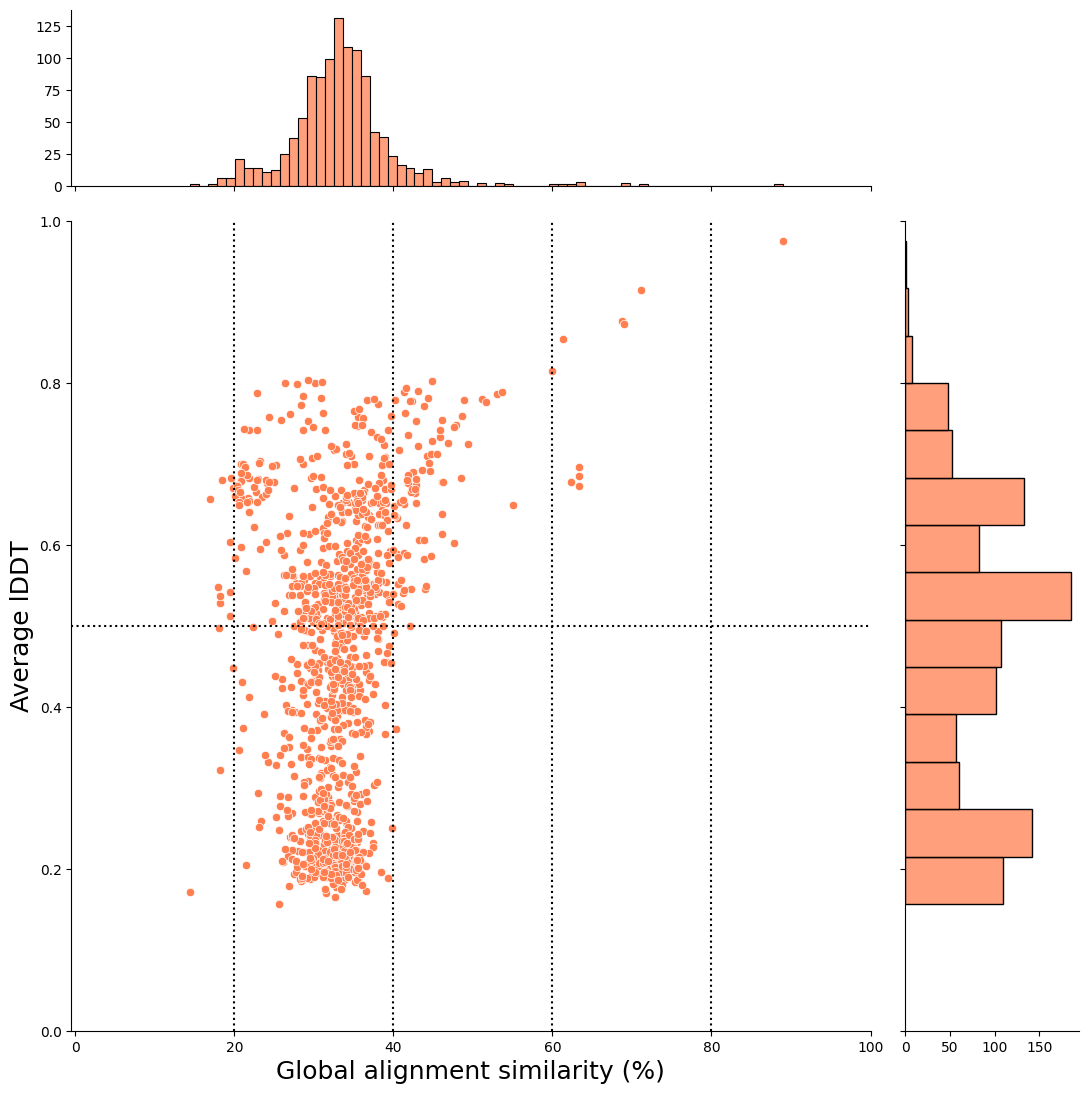

In [19]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 4000x4000 with 0 Axes>

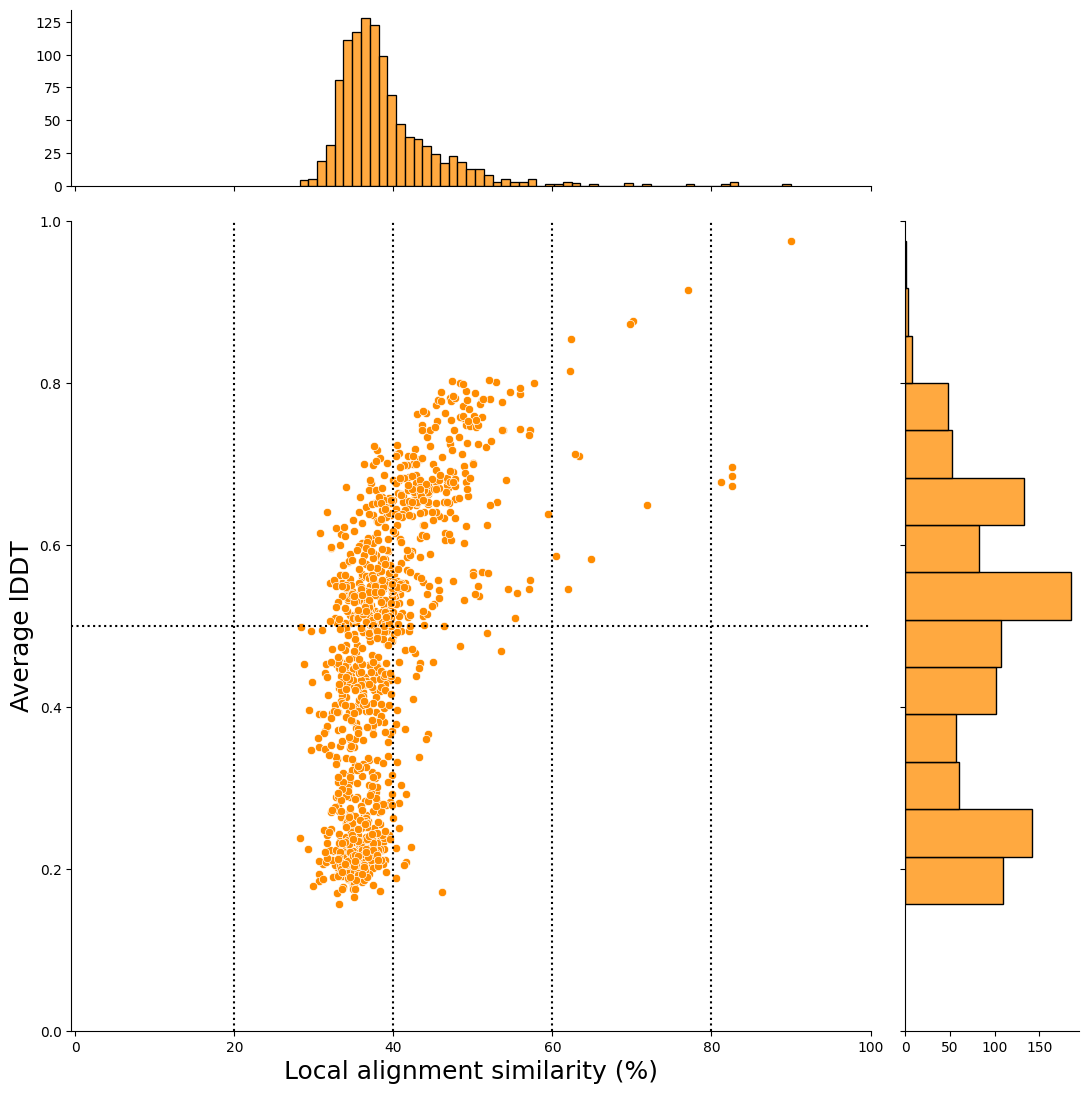

In [20]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_water",
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;
